# Financial Transaction Risk & Fraud Analytics

**Exploratory Data Analysis (EDA) | Python | Pandas | NumPy | Matplotlib | Seaborn**

**Objective:** Analyze financial transactions, identify fraud patterns and balance anomalies, engineer risk-related features, and prepare an analytics-ready dataset for SQL and Power BI.

Financial transaction fraud can create significant financial losses and operational risk. The objective of this analysis is to identify transaction patterns associated with fraudulent activity, evaluate transaction-level risk indicators, compare fraud across transaction types, and provide actionable insights that can support fraud monitoring and investigation.

## 1. Project Setup & Data Loading

Load the transaction dataset and initialize the Python analytics environment.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv('Fraud Payment.csv')

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 2. Data Understanding & Quality Assessment

Inspect dataset structure, dimensions, data types, summary statistics, missing values, and duplicate records.

In [4]:
df.shape

(6362620, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [7]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [8]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## 3. Fraud Distribution & Transaction Analysis

Examine fraud/non-fraud distribution and transaction-type patterns.

In [10]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [11]:
df['isFraud'].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [12]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [13]:
pd.crosstab(
    df['type'],
    df['isFraud'], normalize= True
) * 100

isFraud,0,1
type,,
CASH_IN,21.992261,0.000000
CASH_OUT,35.101641,0.064690
DEBIT,0.651178,0.000000
PAYMENT,33.814608,0.000000
TRANSFER,8.311230,0.064392


## 4. Fraud Amount Investigation

Analyze fraudulent transaction amounts using descriptive statistics and transaction-type aggregation.

In [14]:
fraud_df = df[df['isFraud'] == 1]
fraud_df['amount'].describe()

count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64

In [15]:
fraud_df.groupby('type')['amount'].agg(
    ['count', 'sum', 'mean', 'median', 'max']
).sort_values('sum', ascending=False)

,count,sum,mean,median,max
type,,,,,
TRANSFER,4097,6.067213e+09,1.480892e+06,445705.760,10000000.0
CASH_OUT,4116,5.989202e+09,1.455103e+06,435516.905,10000000.0


## 5. Feature Engineering: Balance & Transaction Anomalies

Create analytical features to detect inconsistencies between transaction amounts and account balance movements.

In [16]:
df["origin_balance_change"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"]
)

In [17]:
df["origin_balance_error"] = (
    df["origin_balance_change"] - df["amount"]
)

In [18]:
df["destination_balance_change"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

In [19]:
df["destination_balance_error"] = (
    df["destination_balance_change"] - df["amount"]
)

In [20]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,origin_balance_change,origin_balance_error,destination_balance_change,destination_balance_error
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,1.455192e-11,0.0,-9839.64
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,-1.136868e-12,0.0,-1864.28
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.000000e+00,0.0,-181.00
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,0.000000e+00,-21182.0,-21363.00
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.000000e+00,0.0,-11668.14


In [21]:
df["origin_zero_balance"] = (
    df["newbalanceOrig"] == 0
)

In [22]:
df["destination_zero_balance"] = (
    df["newbalanceDest"] == 0
)

In [23]:
pd.crosstab(
    df["origin_zero_balance"],
    df["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
origin_zero_balance,,
False,99.994188,0.005812
True,99.776898,0.223102


## 6. High-Value Transaction Analysis

Identify unusually large transactions and evaluate their relationship with fraud occurrence.

In [24]:
df["amount_percentile"] = df["amount"].rank(pct=True)

In [25]:
high_value = df[df["amount_percentile"] >= 0.95]

In [26]:
high_value["isFraud"].mean() * 100

np.float64(1.1954157393786227)

## 7. Risk Scoring & Risk Categorization

Build a rule-based risk score using transaction amount, balance inconsistencies, account balance behavior, and transaction type.

In [27]:
df["risk_score"] = 0

df.loc[
    abs(df["origin_balance_error"]) > 1,
    "risk_score"
] += 30

df.loc[
    df["amount"] > df["amount"].quantile(0.95),
    "risk_score"
] += 25

df.loc[
    df["newbalanceOrig"] == 0,
    "risk_score"
] += 20

df.loc[
    abs(df["destination_balance_error"]) > 1,
    "risk_score"
] += 15

df.loc[
    df["type"].isin(["TRANSFER", "CASH_OUT"]),
    "risk_score"
] += 10

## 8. Risk-Based Fraud Analysis

Compare observed fraud activity across risk categories and transaction characteristics.

In [28]:
df["risk_category"] = pd.cut(
    df["risk_score"],
    bins=[-1, 30, 60, 100],
    labels=["Low", "Medium", "High"]
)

In [29]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,origin_balance_change,origin_balance_error,destination_balance_change,destination_balance_error,origin_zero_balance,destination_zero_balance,amount_percentile,risk_score,risk_category
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,1.455192e-11,0.0,-9839.64,False,True,0.199595,15,Low
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,-1.136868e-12,0.0,-1864.28,False,True,0.041876,15,Low
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.000000e+00,0.0,-181.00,True,True,0.004011,45,Medium
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,0.000000e+00,-21182.0,-21363.00,True,True,0.004011,45,Medium
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.000000e+00,0.0,-11668.14,False,True,0.227101,15,Low


In [30]:
df["risk_score"].value_counts().sort_index()

risk_score
0        27311
10      247599
15     1052709
20          42
25       24640
30        2118
35        1027
45     1380770
50       11225
55        1844
60     1990122
65     1102107
70       22581
75      206307
80          14
85      258003
100      34201
Name: count, dtype: int64

In [31]:
df["risk_category"].value_counts()

risk_category
Medium    3384988
High      1623213
Low       1354419
Name: count, dtype: int64

In [32]:
pd.crosstab(
    df["risk_category"],
    df["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
risk_category,,
Low,99.843697,0.156303
Medium,99.873884,0.126116
High,99.887445,0.112555


In [33]:
pd.crosstab(
    df["type"],
    df["risk_category"],
    normalize="index"
) * 100

risk_category,Low,Medium,High
type,,,
CASH_IN,0.000286,98.514955,1.484759
CASH_OUT,11.348961,78.622749,10.028291
DEBIT,71.560629,25.926820,2.512551
PAYMENT,48.822331,0.000790,51.176879
TRANSFER,3.832362,44.386753,51.780886


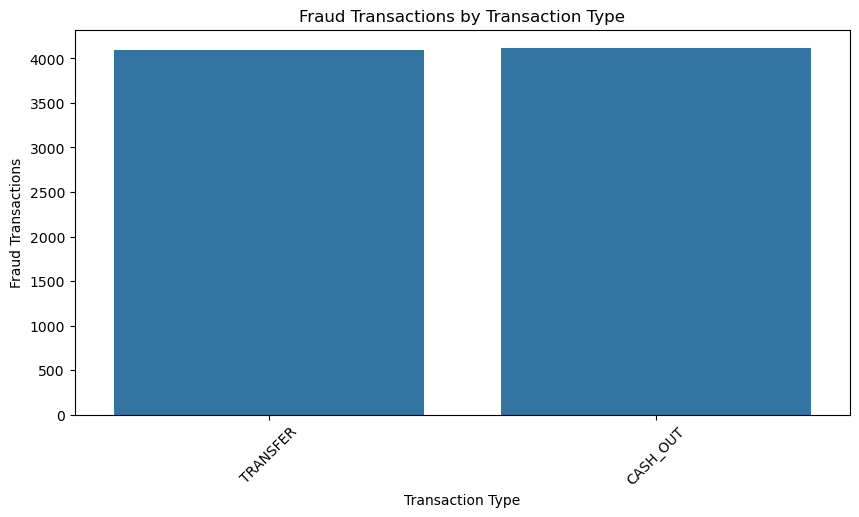

In [34]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df[df["isFraud"] == 1],
    x="type"
)

plt.title("Fraud Transactions by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Transactions")
plt.xticks(rotation=45)
plt.show()

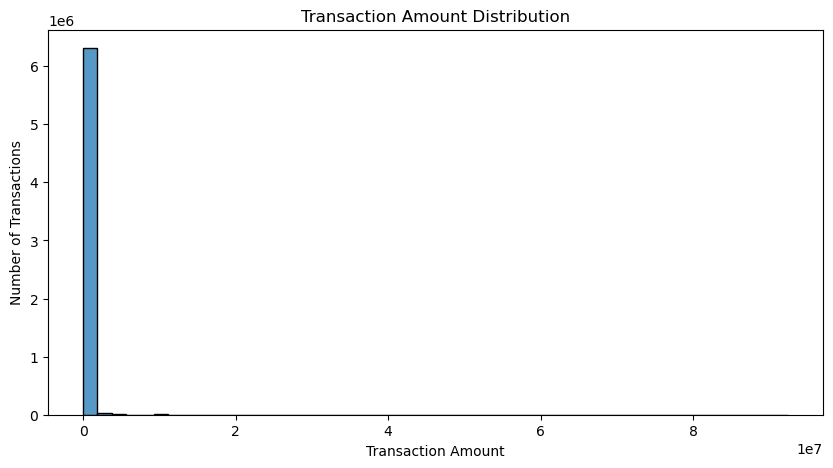

In [35]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="amount",
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.show()

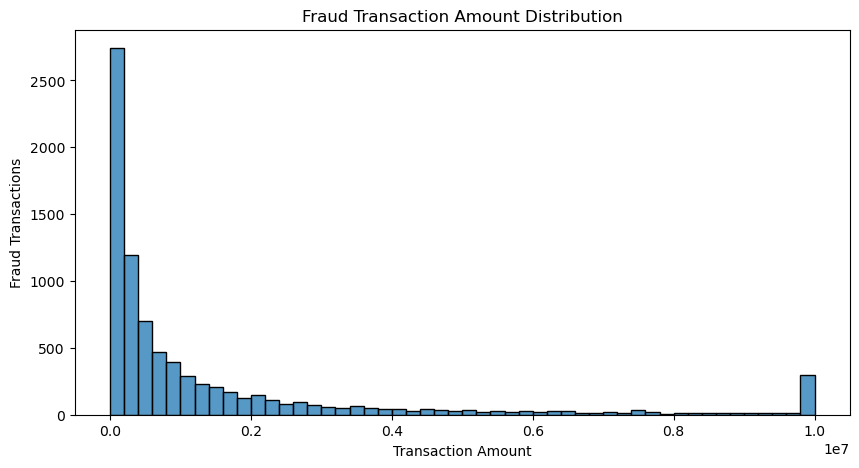

In [36]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=fraud_df,
    x="amount",
    bins=50
)

plt.title("Fraud Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Fraud Transactions")
plt.show()

In [37]:
fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

fraud_rate_by_type

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

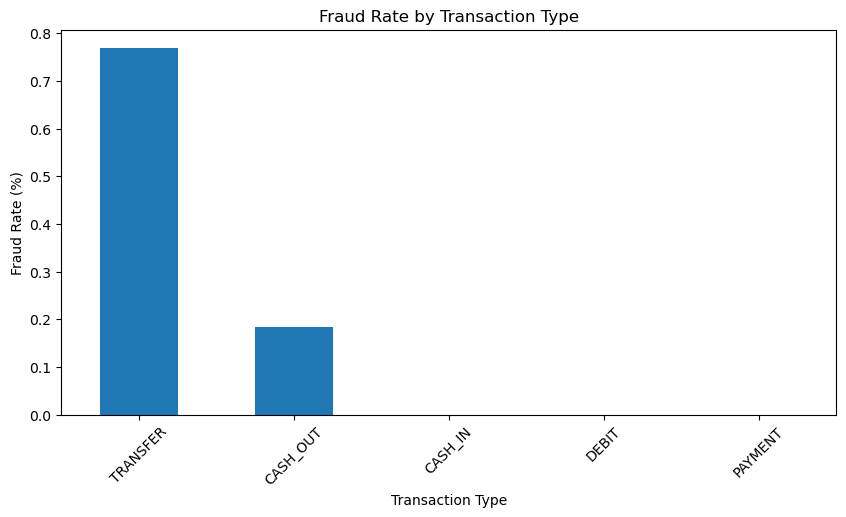

In [38]:
fraud_rate_by_type.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [39]:
high_value_summary = pd.crosstab(
    high_value["isFraud"],
    columns="count"
)

high_value_summary

col_0,count
isFraud,
0,314329
1,3803


In [40]:
print(
    "Fraud rate among high-value transactions:",
    round(high_value["isFraud"].mean() * 100, 2),
    "%"
)

Fraud rate among high-value transactions: 1.2 %


In [41]:
df["balance_anomaly"] = (
    abs(df["origin_balance_error"]) > 1
) | (
    abs(df["destination_balance_error"]) > 1
)

In [42]:
pd.crosstab(
    df["balance_anomaly"],
    df["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
balance_anomaly,,
False,98.587791,1.412209
True,99.929965,0.070035


Which transaction type has the highest fraud rate?

In [43]:
fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

fraud_rate_by_type

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [44]:
fraud_rate_by_type.idxmax()

'TRANSFER'

In [45]:
fraud_rate_by_type.max()

0.7687991758442811

Which transaction type contributes the highest fraud amount?

In [46]:
fraud_amount_by_type = (
    fraud_df.groupby("type")["amount"]
            .sum()
            .sort_values(ascending=False)
)

fraud_amount_by_type

type
TRANSFER    6.067213e+09
CASH_OUT    5.989202e+09
Name: amount, dtype: float64

In [47]:
fraud_amount_by_type.idxmax()

'TRANSFER'

In [48]:
fraud_amount_by_type.max()

6067213184.01

Are high-value transactions more likely to be fraudulent?

In [49]:
high_value_fraud_rate = high_value["isFraud"].mean() * 100

print(
    "Fraud rate among top 5% high-value transactions:",
    round(high_value_fraud_rate, 2),
    "%"
)

Fraud rate among top 5% high-value transactions: 1.2 %


In [50]:
overall_fraud_rate = df["isFraud"].mean() * 100

print(
    "Overall fraud rate:",
    round(overall_fraud_rate, 2),
    "%"
)

print(
    "High-value fraud rate:",
    round(high_value_fraud_rate, 2),
    "%"
)

Overall fraud rate: 0.13 %
High-value fraud rate: 1.2 %


Does balance inconsistency correlate with fraud?

In [51]:
df["balance_anomaly"] = (
    (abs(df["origin_balance_error"]) > 1) |
    (abs(df["destination_balance_error"]) > 1)
)

In [52]:
balance_anomaly_fraud_rate = (
    df.groupby("balance_anomaly")["isFraud"]
      .mean()
      .mul(100)
)

balance_anomaly_fraud_rate

balance_anomaly
False    1.412209
True     0.070035
Name: isFraud, dtype: float64

In [53]:
print(
    "Fraud rate with balance anomaly:",
    round(balance_anomaly_fraud_rate.get(True, 0), 2),
    "%"
)

print(
    "Fraud rate without balance anomaly:",
    round(balance_anomaly_fraud_rate.get(False, 0), 2),
    "%"
)

Fraud rate with balance anomaly: 0.07 %
Fraud rate without balance anomaly: 1.41 %


Which risk category contains the highest fraud concentration?

In [54]:
risk_fraud_rate = (
    df.groupby("risk_category", observed=False)["isFraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

risk_fraud_rate

risk_category
Low       0.156303
Medium    0.126116
High      0.112555
Name: isFraud, dtype: float64

In [55]:
print(
    "Highest fraud concentration:",
    risk_fraud_rate.idxmax()
)

print(
    "Fraud rate:",
    round(risk_fraud_rate.max(), 2),
    "%"
)

Highest fraud concentration: Low
Fraud rate: 0.16 %


Are zero-balance transactions associated with higher fraud?

In [56]:
origin_zero_fraud_rate = (
    df.groupby("origin_zero_balance")["isFraud"]
      .mean()
      .mul(100)
)

origin_zero_fraud_rate

origin_zero_balance
False    0.005812
True     0.223102
Name: isFraud, dtype: float64

In [57]:
destination_zero_fraud_rate = (
    df.groupby("destination_zero_balance")["isFraud"]
      .mean()
      .mul(100)
)

destination_zero_fraud_rate

destination_zero_balance
False    0.105068
True     0.167703
Name: isFraud, dtype: float64

What transaction patterns should investigators prioritize?

In [58]:
investigation_summary = df.groupby("type").agg(
    transactions=("isFraud", "count"),
    fraud_transactions=("isFraud", "sum"),
    fraud_rate=("isFraud", "mean"),
    total_amount=("amount", "sum")
)

investigation_summary["fraud_rate"] *= 100

investigation_summary["fraud_amount"] = (
    df[df["isFraud"] == 1]
    .groupby("type")["amount"]
    .sum()
)

investigation_summary = investigation_summary.sort_values(
    "fraud_rate",
    ascending=False
)

investigation_summary

,transactions,fraud_transactions,fraud_rate,total_amount,fraud_amount
type,,,,,
TRANSFER,532909,4097,0.768799,4.852920e+11,6.067213e+09
CASH_OUT,2237500,4116,0.183955,3.944130e+11,5.989202e+09
CASH_IN,1399284,0,0.000000,2.363674e+11,NaN
DEBIT,41432,0,0.000000,2.271992e+08,NaN
PAYMENT,2151495,0,0.000000,2.809337e+10,NaN


In [59]:
high_risk_transactions = df[
    df["risk_category"] == "High"
].sort_values(
    "risk_score",
    ascending=False
)

high_risk_transactions[
    [
        "step",
        "type",
        "amount",
        "nameOrig",
        "nameDest",
        "risk_score",
        "risk_category",
        "isFraud"
    ]
].head(20)

,step,type,amount,nameOrig,nameDest,risk_score,risk_category,isFraud
717439,37,CASH_OUT,534125.09,C867265273,C186847111,100,High,0
5109644,355,TRANSFER,1680930.77,C1390093542,C108834802,100,High,0
4167026,304,TRANSFER,10000000.00,C1019143413,C1449266892,100,High,0
4167027,304,TRANSFER,10000000.00,C1550823377,C1449266892,100,High,0
96684,10,TRANSFER,3454393.43,C883137443,C2124288420,100,High,0
4167033,304,TRANSFER,3706901.38,C1579329731,C440870460,100,High,0
96700,10,TRANSFER,2555995.32,C765774548,C2075280061,100,High,0
2533593,205,TRANSFER,1025345.27,C1974553291,C356146605,100,High,0
96709,10,CASH_OUT,572178.69,C1742514848,C1632268814,100,High,0
96710,10,TRANSFER,2917742.88,C2126790079,C1778300121,100,High,0


In [60]:
print("===== BUSINESS INSIGHTS =====")

print(
    "1. Highest fraud-rate transaction type:",
    fraud_rate_by_type.idxmax(),
    f"({fraud_rate_by_type.max():.2f}%)"
)

print(
    "2. Highest fraud-amount transaction type:",
    fraud_amount_by_type.idxmax(),
    f"({fraud_amount_by_type.max():,.2f})"
)

print(
    "3. Overall fraud rate:",
    f"{overall_fraud_rate:.2f}%"
)

print(
    "4. High-value transaction fraud rate:",
    f"{high_value_fraud_rate:.2f}%"
)

print(
    "5. Highest-risk category by fraud rate:",
    risk_fraud_rate.idxmax(),
    f"({risk_fraud_rate.max():.2f}%)"
)

===== BUSINESS INSIGHTS =====
1. Highest fraud-rate transaction type: TRANSFER (0.77%)
2. Highest fraud-amount transaction type: TRANSFER (6,067,213,184.01)
3. Overall fraud rate: 0.13%
4. High-value transaction fraud rate: 1.20%
5. Highest-risk category by fraud rate: Low (0.16%)


## 9. Export Analytics-Ready Dataset

Export the engineered dataset for downstream PostgreSQL and Power BI analysis.

In [61]:
df.to_csv(
    "financial_transaction_risk_cleaned.csv",
    index=False
)

In [62]:
df.shape

(6362620, 21)